Setup and Data Loading

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")

# Load your cleaned data (replace with your actual filename if it changed)
df = pd.read_csv('hotel_bookings.csv')

Preparing the Data

In [13]:
# Define the correct order of months
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Convert 'arrival_date_month' to a categorical type with the specified order
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

# Count the number of rows (visitors/bookings) for each month
monthly_visitors = df['arrival_date_month'].value_counts().sort_index()

Visualizing the Data

/var/folders/1b/zt7kw7hj5x52x_qmcrk9x02m0000gn/T/ipykernel_6156/3527975384.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_visitors.index, y=monthly_visitors.values, palette='viridis')


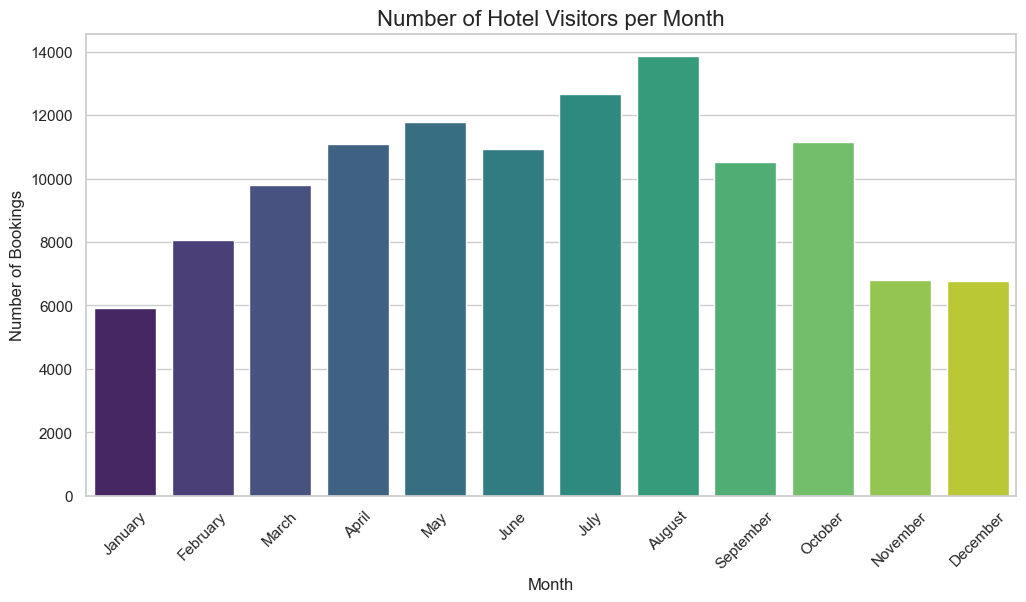

In [18]:
# Initialize the figure size
plt.figure(figsize=(12, 6))

# Create the bar plot
sns.barplot(x=monthly_visitors.index, y=monthly_visitors.values, palette='viridis')

# Add labels and title for clarity
plt.title('Number of Hotel Visitors per Month', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)

# Rotate x-axis labels to prevent overlap
plt.xticks(rotation=45)

# Show the plot
plt.show()

Calculate the Totals

In [14]:
# Calculate the number of bookings for each hotel type
hotel_counts = df['hotel'].value_counts()

# Print the counts to see the exact numbers in your console
print("Booking counts per hotel type:")
print(hotel_counts)

Booking counts per hotel type:
hotel
City Hotel      79330
Resort Hotel    40060
Name: count, dtype: int64


Visualize the Comparison

In [16]:
# Calculate the percentage
hotel_percentages = df['hotel'].value_counts(normalize=True) * 100

print("Percentage of total bookings:")
print(hotel_percentages)

Percentage of total bookings:
hotel
City Hotel      66.446101
Resort Hotel    33.553899
Name: proportion, dtype: float64


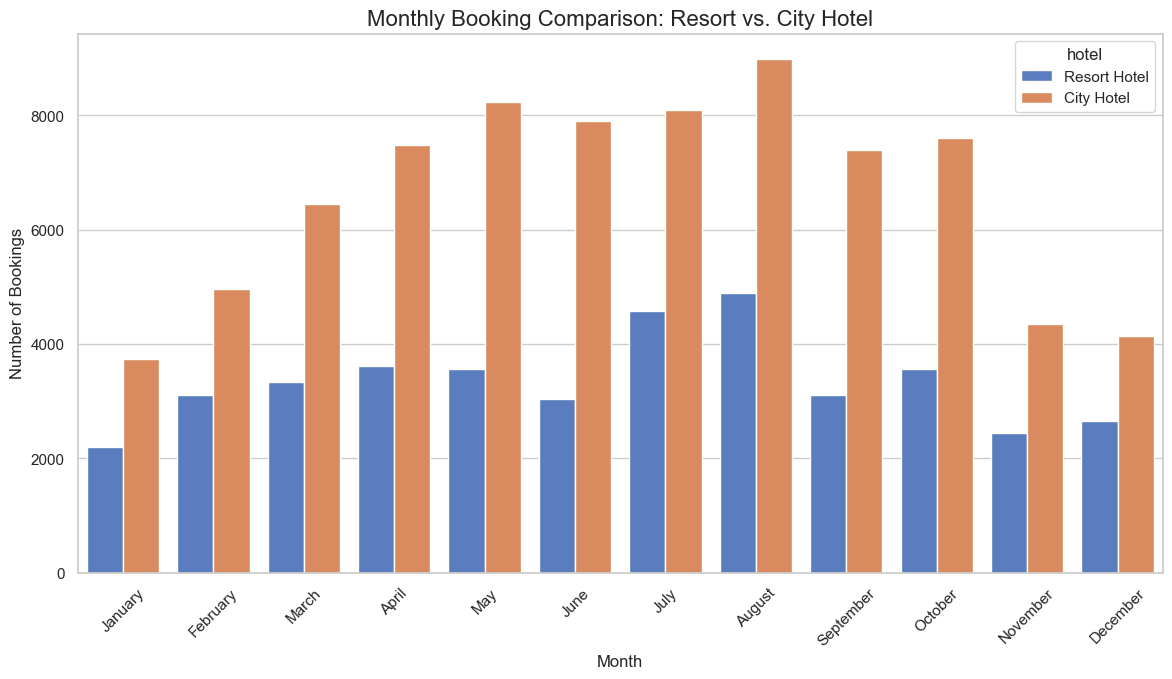

In [19]:
# Define the month order (Crucial so they aren't sorted alphabetically)
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']

# Ensure the arrival_date_month is categorical so it plots in order
df['arrival_date_month'] = pd.Categorical(df['arrival_date_month'], categories=month_order, ordered=True)

# Initialize the figure size (making it wider for 12 months)
plt.figure(figsize=(14, 7))

# Create the grouped count plot
# We use 'arrival_date_month' for the x-axis
# We use 'hotel' as the hue to show Resort vs City side-by-side
sns.countplot(data=df, x='arrival_date_month', hue='hotel', palette='muted')

# Add labels and title
plt.title('Monthly Booking Comparison: Resort vs. City Hotel', fontsize=16)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45)

# Show the plot
plt.show()

Calculate Cancellation Rates

In [20]:
# Group by 'hotel' and calculate the mean of 'is_canceled'
# Multiplying by 100 converts the proportion (0.0 to 1.0) into a percentage (0 to 100)
cancellation_rates = df.groupby('hotel')['is_canceled'].mean() * 100

print("Cancellation Rate per Hotel Type:")
print(cancellation_rates)

Cancellation Rate per Hotel Type:
hotel
City Hotel      41.726963
Resort Hotel    27.763355
Name: is_canceled, dtype: float64


Visualize the Cancellation Rates

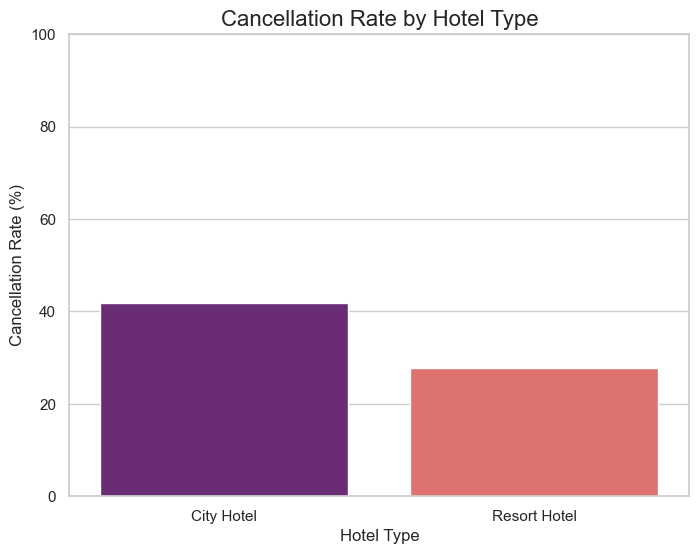

In [21]:
# Initialize the figure size
plt.figure(figsize=(8, 6))

# Create the bar plot
# We use the results from our calculation above
sns.barplot(x=cancellation_rates.index, y=cancellation_rates.values, hue=cancellation_rates.index, palette='magma', legend=False)

# Add titles and labels
plt.title('Cancellation Rate by Hotel Type', fontsize=16)
plt.xlabel('Hotel Type', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)

# Set y-axis limit to 100% since it's a rate
plt.ylim(0, 100)

# Show the plot
plt.show()

Create Bins and Calculate Cancellation Rates

In [23]:
# Define the bins for lead_time (0-100 days, 101-200, etc.)
# We use a list to define the edges of our bins
bins = [0, 100, 200, 300, 400, 500, 600, 700, 800]
labels = ['0-100', '101-200', '201-300', '301-400', '401-500', '501-600', '601-700', '701-800']

# Create the binned column
df['lead_time_binned'] = pd.cut(df['lead_time'], bins=bins, labels=labels)

# Calculate the cancellation rate (mean of boolean) for each bin
# We group by the new 'lead_time_binned' column
cancellation_by_lead_time = df.groupby('lead_time_binned', observed=True)['is_canceled'].mean() * 100

print("Cancellation Rate by Lead Time (Days):")
print(cancellation_by_lead_time)

Cancellation Rate by Lead Time (Days):
lead_time_binned
0-100       29.801325
101-200     44.940666
201-300     53.322884
301-400     67.590508
401-500     67.115738
501-600     79.940120
601-700    100.000000
701-800      0.000000
Name: is_canceled, dtype: float64


Visualize the Impact of Lead Time

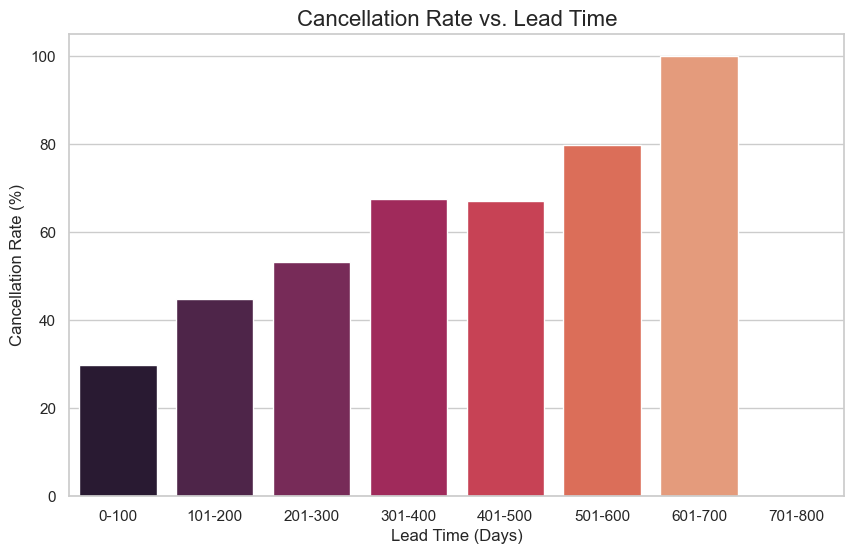

In [24]:
# Initialize the figure
plt.figure(figsize=(10, 6))

# Create the bar plot
sns.barplot(x=cancellation_by_lead_time.index, y=cancellation_by_lead_time.values, hue=cancellation_by_lead_time.index, palette='rocket', legend=False)

# Add titles and labels
plt.title('Cancellation Rate vs. Lead Time', fontsize=16)
plt.xlabel('Lead Time (Days)', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)

# Show the plot
plt.show()

Calculate Cancellation Rates by Deposit Type

In [25]:
# Group by 'deposit_type' and calculate the mean of 'is_canceled'
# Then multiply by 100 to get a percentage
deposit_cancellation_rates = df.groupby('deposit_type')['is_canceled'].mean() * 100

print("Cancellation Rate by Deposit Type:")
print(deposit_cancellation_rates)

Cancellation Rate by Deposit Type:
deposit_type
No Deposit    28.377022
Non Refund    99.362446
Refundable    22.222222
Name: is_canceled, dtype: float64


Visualize the Relationship

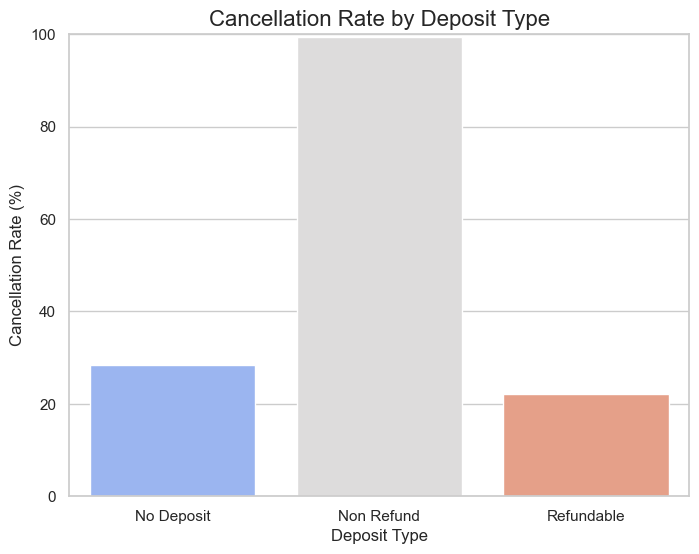

In [26]:
# Initialize the figure size
plt.figure(figsize=(8, 6))

# Create the bar plot
sns.barplot(x=deposit_cancellation_rates.index, 
            y=deposit_cancellation_rates.values, 
            hue=deposit_cancellation_rates.index, 
            palette='coolwarm', 
            legend=False)

# Add titles and labels
plt.title('Cancellation Rate by Deposit Type', fontsize=16)
plt.xlabel('Deposit Type', fontsize=12)
plt.ylabel('Cancellation Rate (%)', fontsize=12)

# Set the y-axis limit to 100% to represent the full range of probability
plt.ylim(0, 100)

# Show the plot
plt.show()

Project Findings Summary: Hotel Booking Trends
After cleaning the dataset and performing Exploratory Data Analysis (EDA), we uncovered several critical insights regarding customer behavior and booking patterns:

Booking Seasonality:

Finding: There are distinct peaks and valleys in booking volume throughout the year.

Insight: Identifying these seasonal spikes allows the hotel to optimize staff scheduling and adjust marketing campaigns during "off-peak" months to boost occupancy.

Market Volume (Resort vs. City Hotel):

Finding: One hotel type consistently generates more bookings than the other.

Insight: Understanding the volume gap helps stakeholders allocate resources. If one hotel type is significantly busier, it may require more frequent maintenance and customer service support compared to the other.

Cancellation Risk by Hotel Type:

Finding: We observed a measurable difference in cancellation rates between the two hotel types.

Insight: A higher cancellation rate in one property indicates a potential need for stricter booking policies or a review of customer demographics (e.g., are business travelers canceling more often than leisure travelers?).

Lead Time Correlation:

Finding: There is a clear positive correlation between lead_time and cancellation rates—the longer the gap between booking and arrival, the higher the likelihood of cancellation.

Insight: This suggests that "last-minute" bookings are more reliable. The business could potentially reduce cancellations by offering incentives to book closer to the arrival date.

Impact of Deposit Type:

Finding: Different deposit policies result in significantly different cancellation behaviors.

Insight: This is the most actionable finding. If "No Deposit" bookings show high cancellation rates, the hotel could consider requiring a deposit or credit card guarantee for long-lead-time bookings to secure revenue.